# Camera Lens Optimization Runner
This notebook provides a structured way to apply evolved black-box optimization algorithms (e.g., from LLaMEA/BLADE) to the **Double-Gauss** camera lens design problem.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import time
import importlib.util

# Setup paths to find the simulation and framework
PROJECT_ROOT = os.path.abspath(".")
CAMERA_LENS_ROOT = os.path.join(PROJECT_ROOT, "camera-lens-simulation")
BLADE_FRAMEWORK_ROOT = os.path.join(PROJECT_ROOT, "blade-framework")

if CAMERA_LENS_ROOT not in sys.path:
    sys.path.insert(0, CAMERA_LENS_ROOT)
if BLADE_FRAMEWORK_ROOT not in sys.path:
    sys.path.insert(0, BLADE_FRAMEWORK_ROOT)

from examples.double_gauss_objective import DoubleGaussObjective
print("Environment initialized correctly.")

Environment initialized correctly.


## 1. Objective Initialization & Benchmark
Load the Double-Gauss objective and calculate the initial template loss for benchmarking.

Problem Dimensions: 24
Initial Template Loss: 0.00055854


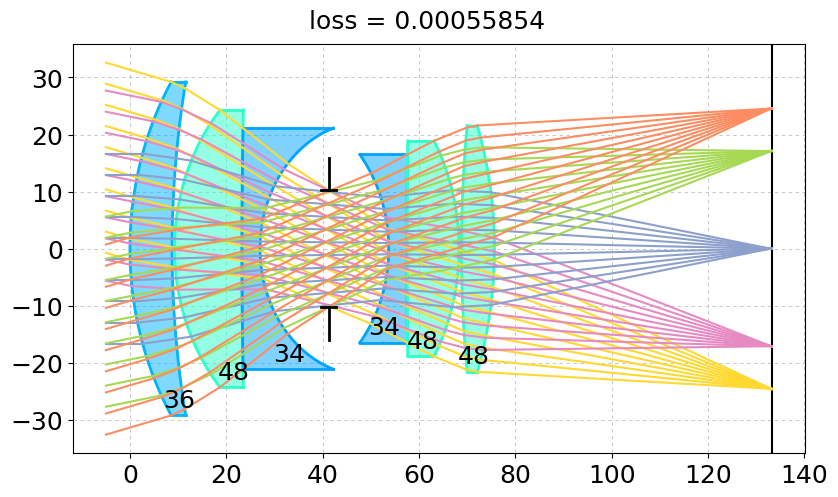

In [3]:
obj = DoubleGaussObjective(enable_grad=False, enable_hessian=False)
lb, ub = obj.bounds()
dim = obj.n_theta

# Initial Benchmark
x0_cont, x0_ids = obj.init_from_templates()
theta0 = obj.pack_theta(x0_cont, x0_ids)
loss0 = obj.objective_theta(theta0)

print(f"Problem Dimensions: {dim}")
print(f"Initial Template Loss: {loss0:.8f}")

# Quick check of the starting point
obj.visualize(theta=theta0, use_latex=False)
plt.show()

## 2. Define or Load Optimizer
Choose **one** of the options below to provide your `Optimizer` class.

In [6]:
# OPTION A: Paste your extracted Optimizer class here
class Optimizer:
    def __init__(self, budget: int, dim: int):
        self.budget = budget
        self.dim = dim

    def __call__(self, func) -> tuple[float, np.ndarray]:
        # Replace with your actual algorithm
        best_f = float('inf')
        best_x = None
        for _ in range(self.budget):
            x = np.random.uniform(-1, 1, self.dim)
            f = func(x)
            if f < best_f:
                best_f = f
                best_x = x
        return best_f, best_x

print("Optimizer Class defined from cell.")

Optimizer Class defined from cell.


In [5]:
# OPTION B: Load Optimizer from a Python file
optimizer_file_path = ""  # e.g., "my_best_optimizer.py"

if optimizer_file_path and os.path.exists(optimizer_file_path):
    spec = importlib.util.spec_from_file_location("custom_opt", optimizer_file_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    Optimizer = module.Optimizer
    print(f"Successfully loaded Optimizer from {optimizer_file_path}")
else:
    print("Using Optimizer defined in the previous cell (Option A).")

Using Optimizer defined in the previous cell (Option A).


## 3. Run Optimization
Execute the selected optimizer against the objective.

In [7]:
budget = 10000
seed = 42
np.random.seed(seed)

print(f"Running {Optimizer.__name__} (Budget={budget}, Seed={seed})...")
optimizer_instance = Optimizer(budget=budget, dim=dim)

def bounded_func(x_normalized):
    x_real = lb + (x_normalized + 1.0) / 2.0 * (ub - lb)
    return obj.objective_theta(np.clip(x_real, lb, ub))

start = time.time()
best_f, best_x_norm = optimizer_instance(bounded_func)
duration = time.time() - start

best_x_real = lb + (best_x_norm + 1.0) / 2.0 * (ub - lb)
best_x_real = np.clip(best_x_real, lb, ub)

print(f"\nOptimization Finished in {duration:.2f}s")
print(f"Initial Loss: {loss0:.6f}")
print(f"Best Loss:    {best_f:.6f}")
print(f"Improvement:  {loss0 - best_f:.6f}")

Running Optimizer (Budget=10000, Seed=42)...

Optimization Finished in 11.99s
Initial Loss: 0.000559
Best Loss:    0.451173
Improvement:  -0.450615


## 4. Visualize Results
Compare the optimized design with the starting point.

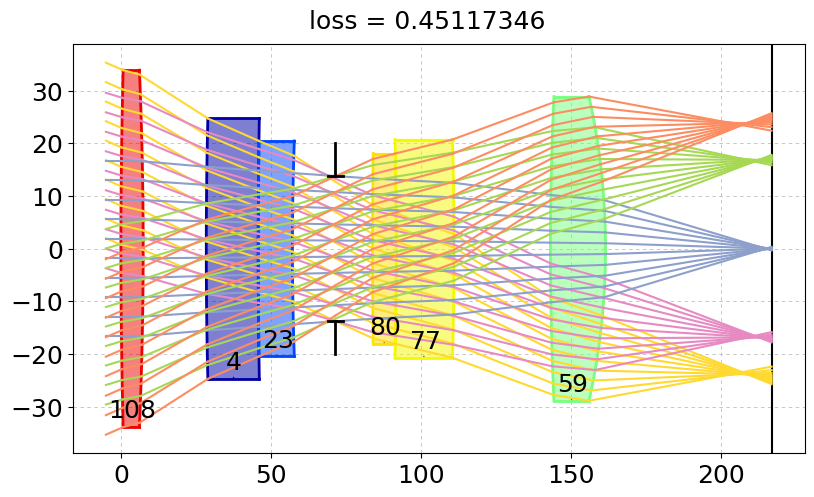

Result saved to lens_visualisation_results/optimized_notebook_1773750442.png


In [9]:
fig, ax, final_loss = obj.visualize(theta=best_x_real, use_latex=False)
plt.show()

# Save the result
os.makedirs("lens_visualisation_results", exist_ok=True)
save_path = f"lens_visualisation_results/optimized_notebook_{int(time.time())}.png"
fig.savefig(save_path)
print(f"Result saved to {save_path}")